# 1. Plot Cool vs Ure rec exemple (2023.11.09 - T1_H3)

### - Thq rec

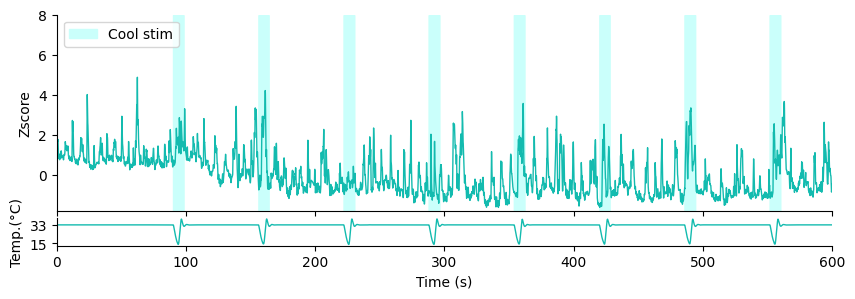

In [2]:

import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter  # Importer la fonction savgol_filter
import pandas as pd

# 1. Chargement des données pour les deux DataFrames
df_cool = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_thq_Zscore_classic.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_cool = '2023.10.07'  # Remplacez par l'animal souhaité
rec_cool = 'Thermic_2'  # Remplacez par le rec souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_cool_filtered = df_cool[(df_cool['animal'] == animal_cool) & (df_cool['rec'] == rec_cool)].copy()

# Conversion du temps en secondes pour les deux DataFrames
df_cool_filtered.loc[:, 'time_sec'] = df_cool_filtered['time'] / 1000

# Appliquer un filtre de lissage (moyenne mobile) sur le Z-score et la température
window_length = 5  # Taille de la fenêtre (doit être impair)
polyorder = 3  # Ordre du polynôme

df_cool_filtered['Z-score_smoothed'] = savgol_filter(df_cool_filtered['Zscore'], window_length=window_length, polyorder=polyorder)


# 4. Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Premier Subplot : Z-score pour les deux conditions
sns.lineplot(x='time_sec', y='Z-score_smoothed', data=df_cool_filtered, ax=ax1, color='#13bbaf', linewidth=1) #label='Cool stim')

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore')
ax1.set_ylim(-1.8, 8)
ax1.set_xlim(0, 600)
# ax1.set_title('Zscore variation for cool and hot stim')

# Définir les périodes "TS" pour les deux DataFrames avec des couleurs transparentes
thermic_color = '#cafffb'  # Couleur pour la période thermic

# Périodes de stimulation thermiques
ts_periods_thermic = df_cool_filtered[df_cool_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_thermic.iterrows():
    start_time_thermic = row['time'] / 1000
    end_time_thermic = (row['time'] + 3900) / 1000  # Conversion en secondes (3.9s)
    ax1.axvspan(start_time_thermic, end_time_thermic, color=thermic_color, zorder=0, label='Cool stim') #if i == 0 else "")

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Deuxième Subplot : Variation de la Température pour les deux DataFrames
sns.lineplot(x='time_sec', y='temperature', data=df_cool_filtered, ax=ax2, color='#13bbaf', linewidth=1)

# Ajuster les labels
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout


# Afficher le graphique
plt.show()


### - Thq Ure rec

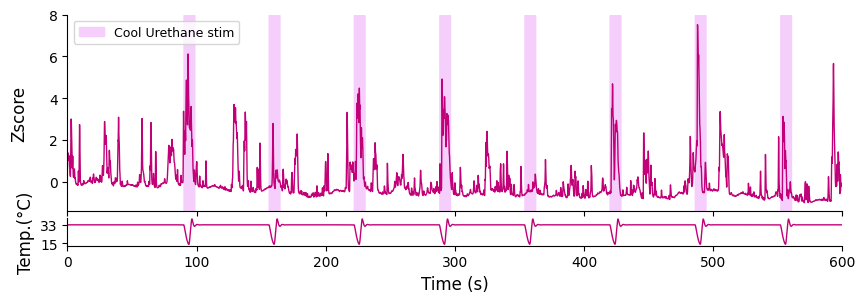

In [4]:

import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter  # Importer la fonction savgol_filter
import pandas as pd

# 1. Chargement des données pour les deux DataFrames
df_cool = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_thq_ure_Zscore_classic.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_cool = '2023.10.06'  # Remplacez par l'animal souhaité
rec_cool = 'urethane_Thc1'  # Remplacez par le rec souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_cool_filtered = df_cool[(df_cool['animal'] == animal_cool) & (df_cool['rec'] == rec_cool)].copy()

# Conversion du temps en secondes pour les deux DataFrames
df_cool_filtered.loc[:, 'time_sec'] = df_cool_filtered['time'] / 1000

# Appliquer un filtre de lissage (moyenne mobile) sur le Z-score et la température
window_length = 5  # Taille de la fenêtre (doit être impair)
polyorder = 3  # Ordre du polynôme

df_cool_filtered['Z-score_smoothed'] = savgol_filter(df_cool_filtered['Zscore'], window_length=window_length, polyorder=polyorder)


# 4. Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Premier Subplot : Z-score pour les deux conditions
sns.lineplot(x='time_sec', y='Z-score_smoothed', data=df_cool_filtered, ax=ax1, color='#c20078', linewidth=1)

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore', labelpad=15)
ax1.set_ylim(-1.4, 8)
ax1.set_xlim(0, 600)
# ax1.set_title('Zscore variation for cool and hot stim')

# Définir les périodes "TS" pour les deux DataFrames avec des couleurs transparentes
thermic_color = '#f6cefc'  # Couleur pour la période thermic

# Périodes de stimulation thermiques
ts_periods_thermic = df_cool_filtered[df_cool_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_thermic.iterrows():
    start_time_thermic = row['time'] / 1000
    end_time_thermic = (row['time'] + 3900) / 1000  # Conversion en secondes (3.9s)
    ax1.axvspan(start_time_thermic, end_time_thermic, color=thermic_color, zorder=0, label='Cool Urethane stim') #if i == 0 else "")

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Deuxième Subplot : Variation de la Température pour les deux DataFrames
sns.lineplot(x='time_sec', y='temperature', data=df_cool_filtered, ax=ax2, color='#c20078', linewidth=1)

# Ajuster les labels
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout


# Afficher le graphique
plt.show()


# 2. Plot PSTC

Valeur maximale de Znorm pour la condition Cool (entre 0 et 3.9 s) : 1.667461791645684
Valeur maximale de Znorm pour la condition Cool Urethane (entre 0 et 3.9 s) : 2.98963710070238


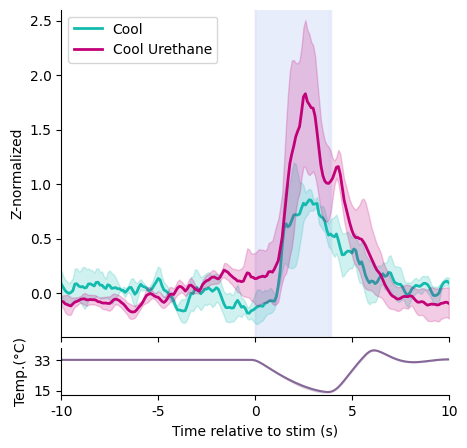

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Répertoires contenant les fichiers Excel
input_directory_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_Thq_Trial_MeanSEM/'
input_directory_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_Thq_ure_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle pour les deux datasets
file_pattern_cool = os.path.join(input_directory_cool, 'Df_thq_Zscore_classic_*_trial_mean_SEM.xlsx')
file_pattern_ure = os.path.join(input_directory_ure, 'Df_thq_ure_Zscore_classic_*_trial_mean_SEM.xlsx')

files_1 = glob.glob(file_pattern_cool)
files_2 = glob.glob(file_pattern_ure)

# Charger et combiner les données de tous les fichiers pour les deux datasets
dfs_1 = []
for file_path in files_1:
    df = pd.read_excel(file_path)
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')
    df['FileName'] = save_file_name
    dfs_1.append(df)

dfs_2 = []
for file_path in files_2:
    df = pd.read_excel(file_path)
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')
    df['FileName'] = save_file_name
    dfs_2.append(df)

# Combiner les deux datasets
df_combined_1 = pd.concat(dfs_1, ignore_index=True)
df_combined_2 = pd.concat(dfs_2, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes pour les deux datasets
df_combined_1['time_sec'] = df_combined_1['Stim_Time'] / 1000
df_combined_2['time_sec'] = df_combined_2['Stim_Time'] / 1000

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer la moyenne et SEM pour le premier dataset
mean_zscore_1 = df_combined_1.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
SEM_zscore_1 = df_combined_1.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Calculer la moyenne et SEM pour le second dataset
mean_zscore_2 = df_combined_2.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
SEM_zscore_2 = df_combined_2.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer la courbe moyenne et l'ombre de SEM pour le premier dataset
ax1.plot(mean_zscore_1['time_sec'], mean_zscore_1['Mean_Znorm'], color='#13bbaf', linewidth=2, linestyle='-', zorder=2, label='Cool')
ax1.fill_between(mean_zscore_1['time_sec'], 
                 mean_zscore_1['Mean_Znorm'] - SEM_zscore_1['Mean_Znorm'], 
                 mean_zscore_1['Mean_Znorm'] + SEM_zscore_1['Mean_Znorm'], 
                 color='#13bbaf', alpha=0.2, zorder=2,)

# Tracer la courbe moyenne et l'ombre de SEM pour le second dataset
ax1.plot(mean_zscore_2['time_sec'], mean_zscore_2['Mean_Znorm'], color='#c20078', linewidth=2, linestyle='-', zorder=2, label='Cool Urethane')
ax1.fill_between(mean_zscore_2['time_sec'], 
                 mean_zscore_2['Mean_Znorm'] - SEM_zscore_2['Mean_Znorm'], 
                 mean_zscore_2['Mean_Znorm'] + SEM_zscore_2['Mean_Znorm'], 
                 color='#c20078', alpha=0.2, zorder=2)


# # Ajouter la période TS en arrière-plan cool stim
color_ts = '#E0E7FC' #'#D4C8DA'

in_ts_period = False
start_time = None
for i, row in df_combined_2.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        ax1.fill_between(df_combined_2['time_sec'], -1, 4, 
                         where=(df_combined_2['time_sec'] >= start_time) & (df_combined_2['time_sec'] <= end_time),
                         color=color_ts, alpha=0.1, zorder=0.5)
        in_ts_period = False


# Tracer les données de température pour chaque dataset
# sns.lineplot(data=df_combined_1, x='time_sec', y='Mean_temperature', color='#a484ac', linewidth=1.5, ax=ax2)
sns.lineplot(data=df_combined_2, x='time_sec', y='Mean_temperature', color='#856798', linewidth=1.5, ax=ax2)

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized')
ax1.legend()
# ax1.set_title('Peristimulus curve for cool vs hot stimulation')

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])
ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])


# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.4, 2.6)
ax1.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

# Ajouter les lignes pour trouver les valeurs maximales de Znorm entre 0 et 3.9 secondes
# Filtrer les données pour la condition Cool entre 0 et 3.9 secondes
condition_cool_filtered = df_combined_1[(df_combined_1['time_sec'] >= 0) & (df_combined_1['time_sec'] <= 3.9)]
max_zscore_cool = condition_cool_filtered['Mean_Znorm'].max()

# Filtrer les données pour la condition Cool Urethane entre 0 et 3.9 secondes
condition_cool_urethane_filtered = df_combined_2[(df_combined_2['time_sec'] >= 0) & (df_combined_2['time_sec'] <= 3.9)]
max_zscore_cool_urethane = condition_cool_urethane_filtered['Mean_Znorm'].max()

# Afficher les valeurs maximales
print(f"Valeur maximale de Znorm pour la condition Cool (entre 0 et 3.9 s) : {max_zscore_cool}")
print(f"Valeur maximale de Znorm pour la condition Cool Urethane (entre 0 et 3.9 s) : {max_zscore_cool_urethane}")



#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 10,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout

# Afficher le graphique
plt.show()


# 3. Ploting AUC for cool vs Urethane

### 3.1. AUC - animals


=== Statistiques par condition et période ===
Cool,TB
0.1716 ± 0.1419, n: 3
Shapiro Stat: 0.9968, Shapiro p-value: 0.8919

Cool,TS
4.2438 ± 0.9517, n: 3
Shapiro Stat: 0.9938, Shapiro p-value: 0.8501

Cool,PTS
1.8555 ± 1.0613, n: 3
Shapiro Stat: 0.9058, Shapiro p-value: 0.4042

Cool Urethane,TB
0.0850 ± 0.0640, n: 3
Shapiro Stat: 0.8531, Shapiro p-value: 0.2487

Cool Urethane,TS
9.1287 ± 3.6951, n: 3
Shapiro Stat: 0.9840, Shapiro p-value: 0.7578

Cool Urethane,PTS
2.3425 ± 1.3615, n: 3
Shapiro Stat: 0.7601, Shapiro p-value: 0.0224



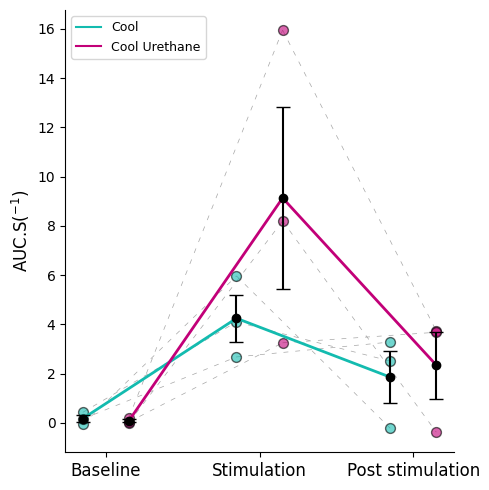

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import os
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_thq_animal.xlsx'
file_path_auc_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_thq_ure_animal.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)
df_auc_ure = pd.read_excel(file_path_auc_ure)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_ure['Condition'] = 'Cool Urethane'

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_cool, df_auc_ure], ignore_index=True)

# Définir les périodes
periods = ['TB', 'TS', 'PTS']

# Filtrer les données par période pour chaque variable
df_periods = {
    'Cool': {period: df_combined[(df_combined['Period'] == period) & (df_combined['Condition'] == 'Cool')] for period in periods},
    'Cool Urethane': {period: df_combined[(df_combined['Period'] == period) & (df_combined['Condition'] == 'Cool Urethane')] for period in periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
offsets = {'AUC_Znorm_persec_cool': -0.15, 'AUC_Znorm_persec_ure': 0.15}
colors = {
    'AUC_Znorm_persec_cool': '#13bbaf',
    'AUC_Znorm_persec_ure': '#c20078'
}
border_colors = {key: 'black' for key in colors}

# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_periods, condition_name, variable_name, color, border_color, offset):
    means = {period: df_periods[condition_name][period][variable_name].mean() for period in periods}
    sems = {period: df_periods[condition_name][period][variable_name].sem() for period in periods}
    for period in periods:
        y_values = df_periods[condition_name][period][variable_name].values
        x_values = [positions[period] + offset] * len(y_values)
        plt.scatter(x_values, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.6, marker='o', s=50, zorder=1)
        mean_value = means[period]
        sem_value = sems[period]
        plt.errorbar(positions[period] + offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems


# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_cool, sems_cool = plot_variable(df_periods, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'], border_colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
means_ure, sems_ure = plot_variable(df_periods, 'Cool Urethane', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_ure'], border_colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_cool = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_cool'], label='Cool')
legend_line_ure = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_ure'], label='Cool Urethane')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_cool, legend_line_ure], loc='upper left')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color, offset):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]] + offset, positions[periods[i + 1]] + offset
        y1, y2 = means[periods[i]], means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_cool, 'AUC_Znorm_persec_cool', colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
plot_connections(means_ure, 'AUC_Znorm_persec_ure', colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])

# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_animal(df_combined, condition_name, variable_name, offset, color):
    # Filtrer par condition et par animal
    for animal in df_combined[df_combined['Condition'] == condition_name]['Animal'].unique():
        animal_data = df_combined[(df_combined['Condition'] == condition_name) & (df_combined['Animal'] == animal)]
        
        # Relier les points pour chaque période pour cet animal
        for i, period in enumerate(periods[:-1]):
            x1 = positions[period] + offset
            x2 = positions[periods[i + 1]] + offset
            y1 = animal_data[animal_data['Period'] == period][variable_name].values[0]
            y2 = animal_data[animal_data['Period'] == periods[i + 1]][variable_name].values[0]
            
            # Tracer une ligne entre les points
            plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10), linewidth=0.5, alpha=0.7, zorder=0)

plot_connections_per_animal(df_combined, 'Cool', 'AUC_Znorm_persec', offsets['AUC_Znorm_persec_cool'], colors['AUC_Znorm_persec_cool'])
plot_connections_per_animal(df_combined, 'Cool Urethane', 'AUC_Znorm_persec', offsets['AUC_Znorm_persec_ure'], colors['AUC_Znorm_persec_ure'])

from scipy.stats import shapiro

# Fonction pour calculer les informations et effectuer le test de Shapiro-Wilk
def calculate_stats(df_periods, variable_name):
    results = []
    for condition, periods_data in df_periods.items():
        for period, data in periods_data.items():
            values = data[variable_name].dropna()  # Supprimer les valeurs NaN
            mean = values.mean()
            sem = values.sem()
            sample_size = len(values)
            shapiro_stat, shapiro_p = shapiro(values) if len(values) >= 3 else (np.nan, np.nan)  # Shapiro nécessite au moins 3 valeurs
            
            # Ajouter les résultats formatés à la liste
            results.append({
                'Condition': condition,
                'Period': period,
                'Mean ± SEM': f"{mean:.4f} ± {sem:.4f}",
                'n': sample_size,
                'Shapiro Stat': f"{shapiro_stat:.4f}" if not np.isnan(shapiro_stat) else "N/A",
                'Shapiro p-value': f"{shapiro_p:.4f}" if not np.isnan(shapiro_p) else "N/A"
            })
    return results

# Calculer les statistiques pour 'AUC_Znorm_persec'
stats_results = calculate_stats(df_periods, 'AUC_Znorm_persec')

# Afficher les résultats
print("\n=== Statistiques par condition et période ===")
for result in stats_results:
    print(f"{result['Condition']},{result['Period']}")
    print(f"{result['Mean ± SEM']}, n: {result['n']}")
    print(f"Shapiro Stat: {result['Shapiro Stat']}, Shapiro p-value: {result['Shapiro p-value']}\n")


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
# plt.grid(axis='y')


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

plt.show()

### 3.2. AUC - trials

Condition  Period     Mean       SEM        n     Shapiro_Stat    Shapiro_p 
----------------------------------------------------------------------
Cool       TB         0.1716     0.0823     48    0.8373          0.0000    
Cool       TS         4.2438     0.9431     48    0.9801          0.5844    
Cool       PTS        1.8555     0.8368     48    0.9555          0.0663    
Ure        TB         0.0850     0.0885     48    0.3148          0.0000    
Ure        TS         9.1287     1.6157     48    0.9378          0.0134    
Ure        PTS        2.3425     1.0204     48    0.9645          0.1532    


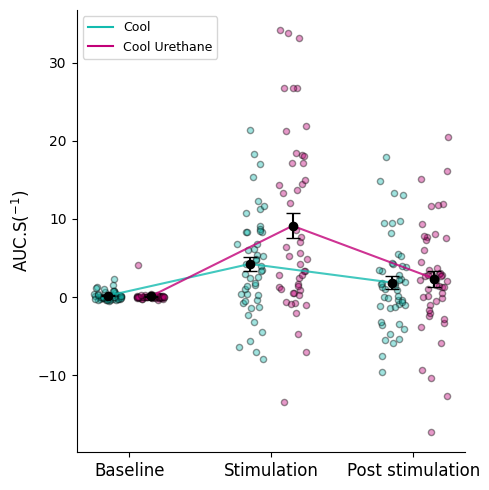

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_thq.xlsx'
file_path_auc_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_thq_ure.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)
df_auc_ure = pd.read_excel(file_path_auc_ure)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['Period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_cool, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']
Conditions = ['Cool', 'Ure']

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Préparer un dictionnaire pour les statistiques
stats_summary = []

# Calcul des statistiques pour chaque condition et période
for condition in Conditions:
    for period in Periods:
        subset = df_combined[(df_combined['Condition'] == condition) & (df_combined['Period_type'] == period)]
        
        if not subset.empty:
            values = subset['AUC_Znorm_persec']
            mean_val = values.mean()
            sem_val = values.sem()
            n_val = len(values)
            
            # Test de Shapiro-Wilk pour la normalité
            shapiro_stat, shapiro_p = shapiro(values)
            
            # Ajouter les résultats dans le résumé
            stats_summary.append({
                'Condition': condition,
                'Period': period,
                'Mean': round(mean_val, 4),
                'SEM': round(sem_val, 4),
                'n': n_val,
                'Shapiro_Stat': round(shapiro_stat, 4),
                'Shapiro_p': round(shapiro_p, 4)
            })

# Afficher les résultats
print(f"{'Condition':<10} {'Period':<10} {'Mean':<10} {'SEM':<10} {'n':<5} {'Shapiro_Stat':<15} {'Shapiro_p':<10}")
print("-" * 70)
for entry in stats_summary:
    print(f"{entry['Condition']:<10} {entry['Period']:<10} {entry['Mean']:<10.4f} {entry['SEM']:<10.4f} {entry['n']:<5} {entry['Shapiro_Stat']:<15.4f} {entry['Shapiro_p']:<10.4f}")


# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
offsets = {'AUC_Znorm_persec_cool': -0.15, 'AUC_Znorm_persec_ure': 0.15}
colors = {
    'AUC_Znorm_persec_cool': '#13bbaf',
    'AUC_Znorm_persec_ure': '#c20078'
}
border_colors = {key: 'black' for key in colors}

# Fonction pour ajouter du jitter aux données
def add_jitter(x_values, jitter_strength=0.1):
    return x_values + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_values))

# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_Periods, condition_name, variable_name, color, border_color, offset):
    means = {Period: df_Periods[condition_name][Period][variable_name].mean() for Period in Periods}
    sems = {Period: df_Periods[condition_name][Period][variable_name].sem() for Period in Periods}
    for Period in Periods:
        y_values = df_Periods[condition_name][Period][variable_name].values
        x_values = [positions[Period] + offset] * len(y_values)
        
        # Ajouter du jitter aux positions des points
        x_values_jittered = add_jitter(x_values)
        
        plt.scatter(x_values_jittered, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.4, marker='o', s=20, zorder=1)
        mean_value = means[Period]
        sem_value = sems[Period]
        plt.errorbar(positions[Period] + offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems

# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_cool, sems_cool = plot_variable(df_Periods, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'], border_colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
means_ure, sems_ure = plot_variable(df_Periods, 'Ure', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_ure'], border_colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_cool = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_cool'], label='Cool')
legend_line_ure = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_ure'], label='Cool Urethane')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_cool, legend_line_ure], loc='upper left')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color, offset):
    for i in range(len(Periods) - 1):
        x1, x2 = positions[Periods[i]] + offset, positions[Periods[i + 1]] + offset
        y1, y2 = means[Periods[i]], means[Periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)

plot_connections(means_cool, 'AUC_Znorm_persec_cool', colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
plot_connections(means_ure, 'AUC_Znorm_persec_ure', colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])


plt.xticks([positions[Period] for Period in Periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

plt.show()


#### Fichier merged Cool-urethane AUC.s-1 for R stat

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_thq.xlsx'
file_path_auc_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_thq_ure.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)
df_auc_ure = pd.read_excel(file_path_auc_ure)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['Period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_cool, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']
Conditions = ['Cool', 'Ure']

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_Combined_thq_ure.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Quantif_by_Periods/AUC_persec_Znorm_Combined_thq_ure.xlsx


# 4. Response rate by condition

### 4.1. with N = animals

Cool condition: Mean = 60.42 ± SEM = 13.66
Urethane condition: Mean = 58.33 ± SEM = 23.20

Résultats des tests de normalité (Shapiro-Wilk) :
Cool: Statistique = 0.8547, p-value = 0.2530
Urethane: Statistique = 0.8710, p-value = 0.2983

Les données sont normalement distribuées. On procède au test t de Student.

Résultats du test t de Student :
Statistique : 0.0774
p-value : 0.9420

Taille des échantillons :
Cool : 3
Urethane : 3


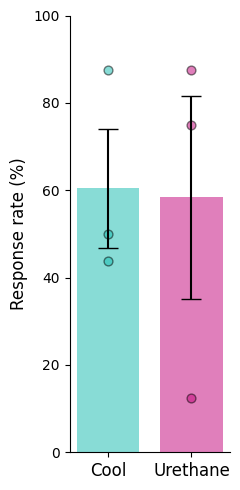

In [11]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Chemins des fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_responsive_rate.xlsx'
file_path_Ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Ure_responsive_rate.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(file_path_cool)
df_Ure = pd.read_excel(file_path_Ure)

# Calcul du taux de réponse moyen par animal pour chaque condition
response_data_cool = df_cool.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_cool['response_rate'] *= 100  # En pourcentage

response_data_Ure = df_Ure.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_Ure['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'condition' pour différencier les groupes
response_data_cool['condition'] = 'Cool'
response_data_Ure['condition'] = 'Urethane'

# Combiner les données des deux conditions
combined_data = pd.concat([response_data_cool, response_data_Ure])

# Calculer la moyenne du taux de réponse par animal pour chaque condition
mean_response_per_animal = combined_data.groupby(['animal', 'condition'])['response_rate'].mean().reset_index()

# Calcul des moyennes et SEM pour chaque condition
mean_response_data = mean_response_per_animal.groupby('condition').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque condition
for condition in mean_response_data['condition']:
    mean_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0]
    print(f"{condition} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque condition
mean_response_cool = mean_response_per_animal[mean_response_per_animal['condition'] == 'Cool']['response_rate']
mean_response_Ure = mean_response_per_animal[mean_response_per_animal['condition'] == 'Urethane']['response_rate']

normality_results = {
    "Cool": stats.shapiro(mean_response_cool),
    "Urethane": stats.shapiro(mean_response_Ure)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for condition, result in normality_results.items():
    print(f"{condition}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")

# Déterminer quel test utiliser
if all(result[1] >= 0.05 for result in normality_results.values()):
    # Test t de Student (normalité respectée)
    print("\nLes données sont normalement distribuées. On procède au test t de Student.")
    t_test_results = stats.ttest_ind(mean_response_cool, mean_response_Ure)
    print("\nRésultats du test t de Student :")
    print(f"Statistique : {t_test_results.statistic:.4f}")
    print(f"p-value : {t_test_results.pvalue:.4f}")
    p_value = t_test_results.pvalue
else:
    # Test de Wilcoxon (normalité non respectée)
    print("\nLes données ne sont pas normalement distribuées. On procède au test de Wilcoxon.")
    wilcoxon_results = stats.wilcoxon(mean_response_cool, mean_response_Ure)
    print("\nRésultats du test de Wilcoxon :")
    print(f"Statistique : {wilcoxon_results.statistic:.4f}")
    print(f"p-value : {wilcoxon_results.pvalue:.4f}")
    p_value = wilcoxon_results.pvalue

# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par condition avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['condition']))

# Barres pour chaque condition
colors = ['#13bbaf', '#c20078']  # Cool (bleu) et Ure (orange)
for i, condition in enumerate(mean_response_data['condition']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0],
        label=f'{condition} Stim', color=colors[i], alpha = 0.5, capsize=7)

# Ajouter des points individuels pour chaque condition
for condition, color in zip(['Cool', 'Urethane'], colors):
    individual_data = mean_response_per_animal[mean_response_per_animal['condition'] == condition]
    plt.scatter(
        [x[0] if condition == 'Cool' else x[1]] * len(individual_data),
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=40  # Taille des points
    )

# Ajouter des barres de significativité
def add_significance_bar(x1, x2, y, p_val, height_offset=1):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1.5, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black')

# Calculer les positions pour les barres de significativité
significance_y_position = max(mean_response_data['mean_response']) + 10  # Ajuster la position pour la significativité
add_significance_bar(x[0], x[1], significance_y_position, p_value)

# Vérification des tailles d'échantillons
sample_size_cool = len(mean_response_cool)  # Taille de l'échantillon pour Cool
sample_size_Ure = len(mean_response_Ure)    # Taille de l'échantillon pour Ure

print("\nTaille des échantillons :")
print(f"Cool : {sample_size_cool}")
print(f"Urethane : {sample_size_Ure}")

# Mise en forme du graphique
# plt.title("response rate by animals")
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['condition'])
plt.ylim(0, 100)
# plt.grid(axis='y', linestyle='--', alpha=0.7)


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Paramètres de style
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Affichage du graphique
plt.tight_layout()

plt.show()


Cool condition: Mean = 60.42 ± SEM = 13.66
Urethane condition: Mean = 58.33 ± SEM = 23.20

Résultats des tests de normalité (Shapiro-Wilk) :
Cool: Statistique = 0.8547, p-value = 0.2530
Urethane: Statistique = 0.8710, p-value = 0.2983

Test de Wilcoxon.

Résultats du test de Wilcoxon :
Statistique : 1.0000
p-value : 0.6547

Taille des échantillons :
Cool : 3
Urethane : 3


c:\Users\zayan\Anaconda\envs\calcium1p\Lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


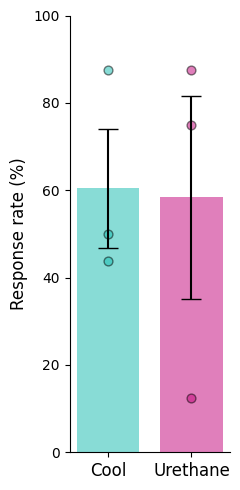

In [12]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Chemins des fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_responsive_rate.xlsx'
file_path_Ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Ure_responsive_rate.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(file_path_cool)
df_Ure = pd.read_excel(file_path_Ure)

# Calcul du taux de réponse moyen par animal pour chaque condition
response_data_cool = df_cool.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_cool['response_rate'] *= 100  # En pourcentage

response_data_Ure = df_Ure.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_Ure['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'condition' pour différencier les groupes
response_data_cool['condition'] = 'Cool'
response_data_Ure['condition'] = 'Urethane'

# Combiner les données des deux conditions
combined_data = pd.concat([response_data_cool, response_data_Ure])

# Calculer la moyenne du taux de réponse par animal pour chaque condition
mean_response_per_animal = combined_data.groupby(['animal', 'condition'])['response_rate'].mean().reset_index()

# Calcul des moyennes et SEM pour chaque condition
mean_response_data = mean_response_per_animal.groupby('condition').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque condition
for condition in mean_response_data['condition']:
    mean_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0]
    print(f"{condition} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque condition
mean_response_cool = mean_response_per_animal[mean_response_per_animal['condition'] == 'Cool']['response_rate']
mean_response_Ure = mean_response_per_animal[mean_response_per_animal['condition'] == 'Urethane']['response_rate']

normality_results = {
    "Cool": stats.shapiro(mean_response_cool),
    "Urethane": stats.shapiro(mean_response_Ure)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for condition, result in normality_results.items():
    print(f"{condition}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")


# Test de Wilcoxon (normalité non respectée)
print("\nTest de Wilcoxon.")
wilcoxon_results = stats.wilcoxon(mean_response_cool, mean_response_Ure)
print("\nRésultats du test de Wilcoxon :")
print(f"Statistique : {wilcoxon_results.statistic:.4f}")
print(f"p-value : {wilcoxon_results.pvalue:.4f}")
p_value = wilcoxon_results.pvalue

# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par condition avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['condition']))

# Barres pour chaque condition
colors = ['#13bbaf', '#c20078']  # Cool (bleu) et Ure (orange)
for i, condition in enumerate(mean_response_data['condition']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0],
        label=f'{condition} Stim', color=colors[i], alpha = 0.5, capsize=7)

# Ajouter des points individuels pour chaque condition
for condition, color in zip(['Cool', 'Urethane'], colors):
    individual_data = mean_response_per_animal[mean_response_per_animal['condition'] == condition]
    plt.scatter(
        [x[0] if condition == 'Cool' else x[1]] * len(individual_data),
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=40  # Taille des points
    )

# Ajouter des barres de significativité
def add_significance_bar(x1, x2, y, p_val, height_offset=1):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1.5, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black')

# Calculer les positions pour les barres de significativité
significance_y_position = max(mean_response_data['mean_response']) + 10  # Ajuster la position pour la significativité
add_significance_bar(x[0], x[1], significance_y_position, p_value)

# Vérification des tailles d'échantillons
sample_size_cool = len(mean_response_cool)  # Taille de l'échantillon pour Cool
sample_size_Ure = len(mean_response_Ure)    # Taille de l'échantillon pour Ure

print("\nTaille des échantillons :")
print(f"Cool : {sample_size_cool}")
print(f"Urethane : {sample_size_Ure}")

# Mise en forme du graphique
# plt.title("response rate by animals")
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['condition'])
plt.ylim(0, 100)
# plt.grid(axis='y', linestyle='--', alpha=0.7)


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Paramètres de style
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Affichage du graphique
plt.tight_layout()

plt.show()


### 4.2. with N = Trials (contengency)

Table de contingence :
Urethane   0   1
Cool            
0          9  10
1         11  18

Tailles d'échantillon par condition :
condition
Cool        48
Urethane    48
dtype: int64

Moyennes des réponses 1 par condition :
response_rate
0    40.625
1    59.375
dtype: float64

Résultat du test de McNemar :
Statistique : 10.0, p-value : 1.0


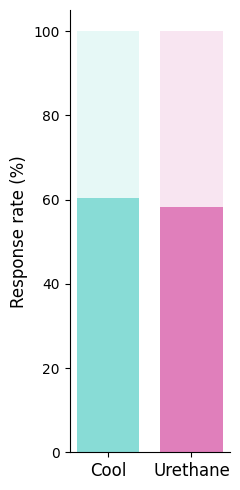

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar

# Chargement des données (déjà fait dans ton code précédent)
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_responsive_rate.xlsx'
file_path_Ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_responsive_rate.xlsx'

df_cool = pd.read_excel(file_path_cool)
df_Ure = pd.read_excel(file_path_Ure)

# Ajout de la colonne 'condition' pour différencier les groupes
df_cool['condition'] = 'Cool'
df_Ure['condition'] = 'Urethane'

# Combiner les données des deux conditions
combined_data = pd.concat([df_cool, df_Ure])

# response_counts = combined_data.groupby(['condition', 'response_rate']).size().unsurek(fill_value=0)
response_counts = combined_data.groupby(['condition', 'response_rate']).size().unstack(fill_value=0)

# Calcul des pourcentages de réponses 0 et 1 pour chaque condition
response_percentages = response_counts.div(response_counts.sum(axis=1), axis=0) * 100

# Création d'une table de contingence pour McNemar
# Comparaison des réponses 0 et 1 pour Cool et Ure
contingency_table = pd.crosstab(combined_data['response_rate'][combined_data['condition'] == 'Cool'],
                                combined_data['response_rate'][combined_data['condition'] == 'Urethane'],
                                rownames=['Cool'], colnames=['Urethane'])

# Test de McNemar
result = mcnemar(contingency_table, exact=True)

# Affichage des résultats du test de McNemar
print("Table de contingence :")
print(contingency_table.to_string())  # Format amélioré pour une meilleure lisibilité

# Calcul des tailles d'échantillon et des moyennes
sample_sizes = combined_data.groupby('condition').size()
means = response_percentages.mean()

# Affichage des tailles d'échantillon et des moyennes
print("\nTailles d'échantillon par condition :")
print(sample_sizes)

print("\nMoyennes des réponses 1 par condition :")
print(means)

print("\nRésultat du test de McNemar :")
print(f"Statistique : {result.statistic}, p-value : {result.pvalue}")

# Vérification de la significativité
if result.pvalue < 0.001:
    significance = "***"
elif result.pvalue < 0.01:
    significance = "**"
elif result.pvalue < 0.05:
    significance = "*"
else:
    significance = "ns"  # Pas significatif

# Création du graphique (bar chart avec les pourcentages)
fig, ax = plt.subplots(figsize=(2.5, 5))

# Tracer la partie des barres correspondant à la réponse 1 (en couleur pleine et alpha = 0.5) pour Cool
ax.bar('Cool', response_percentages.loc['Cool', 1], color='#13bbaf', alpha=0.5, label='Réponse 1 (Cool)', width=0.75)

# Tracer la partie des barres correspondant à la réponse 0 (en couleur transparente et alpha = 0.1) pour Cool
ax.bar('Cool', response_percentages.loc['Cool', 0], color='#13bbaf', alpha=0.1, label='Réponse 0 (Cool)', width=0.75, bottom=response_percentages.loc['Cool', 1])

# Tracer la partie des barres correspondant à la réponse 1 (en couleur pleine et alpha = 0.5) pour Ure
ax.bar('Urethane', response_percentages.loc['Urethane', 1], color='#c20078', alpha=0.5, label='Réponse 1 (Urethane)', width=0.75)

# Tracer la partie des barres correspondant à la réponse 0 (en couleur transparente et alpha = 0.1) pour Ure
ax.bar('Urethane', response_percentages.loc['Urethane', 0], color='#c20078', alpha=0.1, label='Réponse 0 (Urethane)', width=0.75, bottom=response_percentages.loc['Urethane', 1])

# Ajouter une barre de significativité si la différence est significative
if result.pvalue < 0.05:
    # Calculer la position de la barre
    y_bar = max(response_percentages.loc['Cool', 1], response_percentages.loc['Urethane', 1]) + 10  # Position verticale

    # Tracer la barre horizontale
    ax.plot([0, 1], [y_bar, y_bar], color='black', lw=1)

    # Ajouter de petites barres verticales aux extrémités
    cap_height = 1  # Hauteur des petites barres
    ax.plot([0, 0], [y_bar - cap_height, y_bar], color='black', lw=1)  # Cap à gauche
    ax.plot([1, 1], [y_bar - cap_height, y_bar], color='black', lw=1)  # Cap à droite

    # Ajouter les étoiles pour indiquer la significativité
    ax.text(0.5, max(response_percentages.loc['Cool', 1], response_percentages.loc['Urethane', 1]) + 10,
            significance, ha='center', color='black')

# Personnalisation du graphique
ax.set_ylabel('Response rate (%)')
ax.set_xlabel('')
ax.set_xticks(['Cool', 'Urethane'])
ax.set_xticklabels(['Cool', 'Urethane'])

ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Paramètres de style
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Affichage du graphique
fig.tight_layout()
plt.show()


### 4.3 with N = Trials


Résultats des tests de normalité (Shapiro-Wilk) :
Cool: Statistique = 0.6209, p-value = 0.0000
Ure: Statistique = 0.6267, p-value = 0.0000

Statistiques des réponses par condition :
Cool : Mean = 60.4167 ± SEM = 7.1332, n = 48
Urethane : Mean = 58.3333 ± SEM = 7.1912, n = 48

Résultats du test de Wilcoxon :
Statistique = 110.0000
p-value = 0.8273

Nombre d'observations uniques pour la condition Cool : 48
Nombre d'observations uniques pour la condition Ure : 48

Taille des échantillons :
Cool : 48
Ure : 48


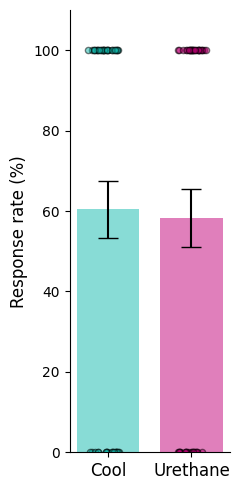

In [14]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np 

# Chemins des fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_responsive_rate.xlsx'
file_path_Ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_responsive_rate.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(file_path_cool)
df_Ure = pd.read_excel(file_path_Ure)

# Calcul du taux de réponse moyen par trial pour chaque condition
response_data_cool = df_cool.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_cool['response_rate'] *= 100  # En pourcentage

response_data_Ure = df_Ure.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_Ure['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'condition' pour différencier les groupes
response_data_cool['condition'] = 'Cool'
response_data_Ure['condition'] = 'Urethane'

# Combiner les données des deux conditions
combined_data = pd.concat([response_data_cool, response_data_Ure])

# Vérifier la normalité (Shapiro-Wilk) pour chaque condition
mean_response_cool = response_data_cool['response_rate']
mean_response_Ure = response_data_Ure['response_rate']

normality_results = {
    "Cool": stats.shapiro(mean_response_cool),
    "Ure": stats.shapiro(mean_response_Ure)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for condition, result in normality_results.items():
    print(f"{condition}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")

# Calcul des moyennes, SEM, et tailles d'échantillon pour chaque condition
mean_response_data = combined_data.groupby('condition')['response_rate'].agg(['mean', 'sem']).reset_index()

# Calcul de la taille d'échantillon pour chaque condition
n_data = combined_data.groupby('condition').size().reset_index(name='n')

# Renommer les colonnes pour faciliter l'accès
mean_response_data.columns = ['condition', 'mean_response', 'sem_response']
mean_response_data = pd.merge(mean_response_data, n_data, on='condition')

# Afficher les moyennes, SEM et n
print("\nStatistiques des réponses par condition :")
for index, row in mean_response_data.iterrows():
    print(f"{row['condition']} : Mean = {row['mean_response']:.4f} ± SEM = {row['sem_response']:.4f}, n = {row['n']}")

# Choisir le test approprié en fonction des résultats de normalité
if all(result[1] > 0.05 for result in normality_results.values()):
    # Si les deux distributions sont normales, on utilise le test t de Student apparié
    test_name = "test t de Student apparié"
    test_results = stats.ttest_rel(mean_response_cool, mean_response_Ure)
else:
    # Sinon, on utilise le test de Wilcoxon
    test_name = "test de Wilcoxon"
    test_results = stats.wilcoxon(mean_response_cool, mean_response_Ure)

# Affichage des résultats du test statistique approprié
print(f"\nRésultats du {test_name} :")
print(f"Statistique = {test_results.statistic:.4f}")
print(f"p-value = {test_results.pvalue:.4f}")
p_value = test_results.pvalue

# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par condition avec sem
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['condition']))

# Barres pour la condition Cool
plt.bar(x[0],
        mean_response_data.loc[mean_response_data['condition'] == 'Cool', 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['condition'] == 'Cool', 'sem_response'].values[0],
        label='Cool Stim', color='#13bbaf', alpha = 0.5, capsize=7)

# Barres pour la condition Ure
plt.bar(x[1],
        mean_response_data.loc[mean_response_data['condition'] == 'Urethane', 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['condition'] == 'Urethane', 'sem_response'].values[0],
        label='Ure Stim', color='#c20078', alpha = 0.5, capsize=7)

# Ajouter des points individuels pour chaque condition avec jitter
colors = ['#13bbaf', '#c20078']  # Couleurs pour Cool et Ure
for condition, color, x_coord in zip(['Cool', 'Urethane'], colors, x):
    individual_data = combined_data[combined_data['condition'] == condition]
    jitter = np.random.normal(0, 0.1, size=len(individual_data))  # Jitter aléatoire autour de x_coord
    plt.scatter(
        x_coord + jitter,  # Ajout du jitter à la position x
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=20  # Taille des points
    )

# Fonction pour ajouter les barres de significativité
def add_significance_bar(x1, x2, y, p_val, height_offset=1):
    """
    Fonction pour ajouter des barres de significativité entre deux groupes avec un offset dynamique.
    """
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1.5, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black')

# Calculer les positions pour les barres de significativité
significance_y_position = max(mean_response_data['mean_response']) + 10  # Ajuster la position pour la significativité
add_significance_bar(x[0], x[1], significance_y_position, p_value)

# plt.title("Response rate by condition")
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['condition'])  # Les xticks sont maintenant centrés
plt.ylim(0, 110)
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# Calcul du nombre d'observations uniques (animal-rec-trial) pour chaque condition
n_cool = len(df_cool[['animal', 'rec', 'trial']].drop_duplicates())
n_Ure = len(df_Ure[['animal', 'rec', 'trial']].drop_duplicates())

print(f"\nNombre d'observations uniques pour la condition Cool : {n_cool}")
print(f"Nombre d'observations uniques pour la condition Ure : {n_Ure}")

# Vérification des tailles d'échantillons
sample_size_cool = len(mean_response_cool)  # Taille de l'échantillon pour Cool
sample_size_Ure = len(mean_response_Ure)    # Taille de l'échantillon pour Ure

print("\nTaille des échantillons :")
print(f"Cool : {sample_size_cool}")
print(f"Ure : {sample_size_Ure}")

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

plt.show()


# 5. Above threshold rate

### 5.1. with n = animals


Test de normalité : TB (Cool)
Stat = 0.9552, p-value = 0.5928

Test de normalité : TB (ure)
Stat = 0.9323, p-value = 0.4974

Test de normalité : TS (Cool)
Stat = 0.8838, p-value = 0.3356

Test de normalité : TS (ure)
Stat = 0.9948, p-value = 0.8623

Test de normalité : PTS (Cool)
Stat = 0.7881, p-value = 0.0865

Test de normalité : PTS (ure)
Stat = 0.8907, p-value = 0.3566

Cool - Période TB : 2.4375 ± 0.8861, n = 3

ure - Période TB : 1.6250 ± 0.8409, n = 3

Cool - Période TS : 12.6322 ± 2.3893, n = 3

ure - Période TS : 21.9973 ± 10.3067, n = 3

Cool - Période PTS : 5.8798 ± 2.4912, n = 3

ure - Période PTS : 7.9322 ± 3.1450, n = 3


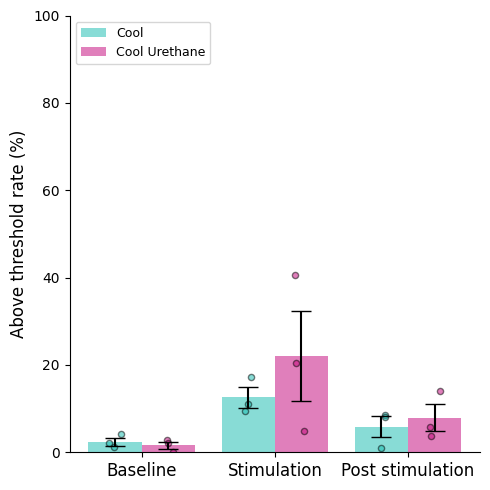

In [18]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Norm_response_rate.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool, df_ure], ['Cool', 'ure']):

    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_cool_animal = df_cool.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()
mean_ure_animal = df_ure.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()


# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = mean_cool_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_cool = mean_cool_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

mean_ure = mean_ure_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_ure = mean_ure_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['Norm_response_rate'],
    'sem_response_cool': sem_cool['Norm_response_rate'],
    'mean_response_ure': mean_ure['Norm_response_rate'],
    'sem_response_ure': sem_ure['Norm_response_rate']
})

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    for cond in ['Cool', 'ure']:
        data_subset = mean_cool_animal if cond == 'Cool' else mean_ure_animal
        period_data = data_subset[data_subset['period_type'] == period]['Norm_response_rate']

        # Affichage du nombre d'observations (n)
        n = len(period_data)
        print(f"\nTest de normalité : {period} ({cond})")

        stat, p_value = shapiro(period_data)
        normality_results[period][cond] = {'statistic': stat, 'p_value': p_value}
        print(f'Stat = {stat:.4f}, p-value = {p_value:.4f}')

# Calculer la mean ± SEM et la taille de l'échantillon (n) pour chaque condition et période
for period in ['TB', 'TS', 'PTS']:
    for cond in ['Cool', 'ure']:
        data_subset = mean_cool_animal if cond == 'Cool' else mean_ure_animal
        period_data = data_subset[data_subset['period_type'] == period]['Norm_response_rate']

        # Calcul de la moyenne, SEM et taille de l'échantillon
        mean_value = period_data.mean()
        sem_value = period_data.sem()
        n_value = len(period_data)

        # Affichage des résultats avec 4 chiffres après la virgule
        print(f"\n{cond} - Période {period} : {mean_value:.4f} ± {sem_value:.4f}, n = {n_value}")


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Cool Urethane', color='#c20078', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = mean_cool_animal[mean_cool_animal['period_type'] == period]['Norm_response_rate']
    ure_values = mean_ure_animal[mean_ure_animal['period_type'] == period]['Norm_response_rate']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.05  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.5)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#c20078', edgecolor='black', s=20, alpha=0.5)


# Titres et légendes
plt.xlabel('')
# plt.title("Norm_response_rate by conditions (N = trials)")
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()


plt.show()


### 5.2. with n = Trials

Cool-TB : 2.4375 ± 0.5173, n = 48
ure-TB : 1.6250 ± 0.5567, n = 48
Cool-TS : 12.6322 ± 2.0955, n = 48
ure-TS : 21.9973 ± 3.5048, n = 48
Cool-PTS : 5.8798 ± 1.5143, n = 48
ure-PTS : 7.9322 ± 1.8322, n = 48

Test de normalité Shapiro
Cool-TB : Stat = 0.7292, p-value = 0.0000

Test de normalité Shapiro
ure-TB : Stat = 0.4835, p-value = 0.0000

Test de normalité Shapiro
Cool-TS : Stat = 0.8283, p-value = 0.0000

Test de normalité Shapiro
ure-TS : Stat = 0.8359, p-value = 0.0000

Test de normalité Shapiro
Cool-PTS : Stat = 0.6232, p-value = 0.0000

Test de normalité Shapiro
ure-PTS : Stat = 0.6904, p-value = 0.0000


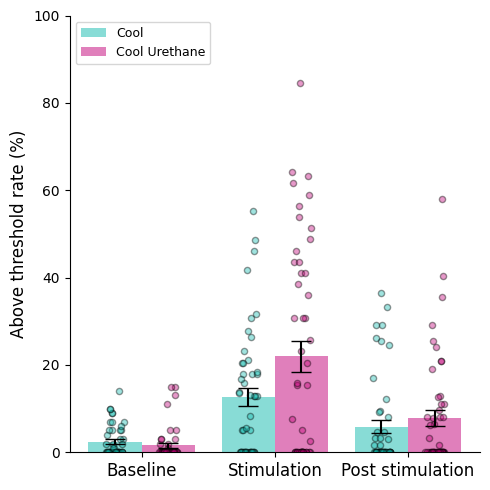

In [21]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare


# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Norm_response_rate.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool, df_ure], ['Cool', 'ure']):

    
    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')
    
    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]

# Extraire le type de période (TS, TB, PTS)
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_cool_filtered = df_cool[df_cool['period_type'].isin(['TS', 'TB', 'PTS'])]
df_ure_filtered = df_ure[df_ure['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = df_cool_filtered.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_cool = df_cool_filtered.groupby('period_type')['Norm_response_rate'].sem().reset_index()

mean_ure = df_ure_filtered.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_ure = df_ure_filtered.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['Norm_response_rate'],
    'sem_response_cool': sem_cool['Norm_response_rate'],
    'mean_response_ure': mean_ure['Norm_response_rate'],
    'sem_response_ure': sem_ure['Norm_response_rate']
})


# Afficher les résultats de la moyenne ± SEM et la taille de l'échantillon pour chaque condition et période
for period in ['TB', 'TS', 'PTS']:
    for cond, mean_data, sem_data in zip(['Cool', 'ure'], [mean_cool, mean_ure], [sem_cool, sem_ure]):
        # Sélectionner les données pour la période et condition données
        period_data = df_cool_filtered if cond == 'Cool' else df_ure_filtered
        period_values = period_data[period_data['period_type'] == period]['Norm_response_rate']
        
        # Calculer la taille de l'échantillon
        n = len(period_values)
        
        # Trouver la moyenne et SEM pour la condition et la période données
        mean_value = mean_data[mean_data['period_type'] == period]['Norm_response_rate'].values[0]
        sem_value = sem_data[sem_data['period_type'] == period]['Norm_response_rate'].values[0]
        
        # Afficher les résultats avec 4 chiffres après la virgule
        print(f"{cond}-{period} : {mean_value:.4f} ± {sem_value:.4f}, n = {n}")


# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    for cond in ['Cool', 'ure']:
        data_subset = df_cool_filtered if cond == 'Cool' else df_ure_filtered
        period_data = data_subset[data_subset['period_type'] == period]['Norm_response_rate']
        
        # Affichage du nombre d'observations (n)
        n = len(period_data)
        print(f"\nTest de normalité Shapiro")
        
        stat, p_value = shapiro(period_data)
        normality_results[period][cond] = {'statistic': stat, 'p_value': p_value}
        print(f'{cond}-{period} : Stat = {stat:.4f}, p-value = {p_value:.4f}')


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Cool Urethane', color='#c20078', alpha=0.5, capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = df_cool_filtered[df_cool_filtered['period_type'] == period]['Norm_response_rate']
    ure_values = df_ure_filtered[df_ure_filtered['period_type'] == period]['Norm_response_rate']
     # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.07  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#c20078', edgecolor='black', s=20, alpha=0.4)


# Titres et légendes
plt.xlabel('')
# plt.title("Norm_response_rate by conditions (N = trials)")
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim (0,100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()



plt.show()


#### Fichier merged Cool-urethane above threshold for R stat

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Norm_response_rate.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_Norm_response_rate.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(cool_file_path)
df_auc_ure = pd.read_excel(ure_file_path)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_cool, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']
Conditions = ['Cool', 'Ure']

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Above_Threshold_Combined_thq_ure.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Above_Threshold_Combined_thq_ure.xlsx


# 6. Magnitude of the response

### 6.1. N = animals 


Test de normalité Shapiro
Cool-TB : Stat = 0.9759, p-value = 0.7020
Cool-TB : mean = 0.0581 ± 0.0213, n = 3

Test de normalité Shapiro
ure-TB : Stat = 0.8198, p-value = 0.1626
ure-TB : mean = 0.0469 ± 0.0235, n = 3

Test de normalité Shapiro
Cool-TS : Stat = 0.8610, p-value = 0.2703
Cool-TS : mean = 0.3154 ± 0.0608, n = 3

Test de normalité Shapiro
ure-TS : Stat = 0.9978, p-value = 0.9103
ure-TS : mean = 0.8147 ± 0.3457, n = 3

Test de normalité Shapiro
Cool-PTS : Stat = 0.8161, p-value = 0.1536
Cool-PTS : mean = 0.1518 ± 0.0659, n = 3

Test de normalité Shapiro
ure-PTS : Stat = 0.9845, p-value = 0.7618
ure-PTS : mean = 0.2306 ± 0.0893, n = 3


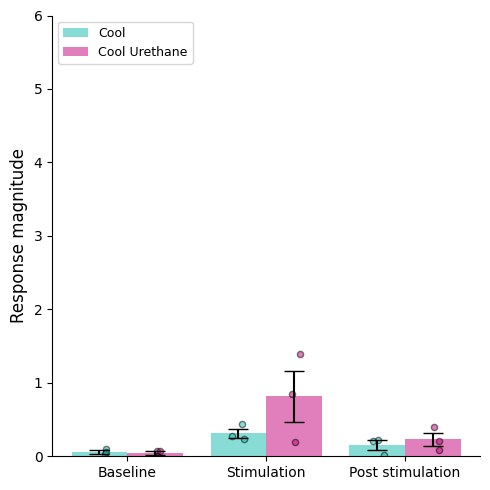

In [28]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Response_Magnitude.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_Response_Magnitude.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool, df_ure], ['Cool', 'ure']):

    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]


# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_cool_animal = df_cool.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()
mean_ure_animal = df_ure.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = mean_cool_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_cool = mean_cool_animal.groupby('period_type')['response_magnitude'].sem().reset_index()

mean_ure = mean_ure_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_ure = mean_ure_animal.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['response_magnitude'],
    'sem_response_cool': sem_cool['response_magnitude'],
    'mean_response_ure': mean_ure['response_magnitude'],
    'sem_response_ure': sem_ure['response_magnitude']
})

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    for cond in ['Cool', 'ure']:
        data_subset = mean_cool_animal if cond == 'Cool' else mean_ure_animal
        period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']

        # Affichage du nombre d'observations (n)
        n = len(period_data)

        stat, p_value = shapiro(period_data)
        normality_results[period][cond] = {'statistic': stat, 'p_value': p_value}

        print(f"\nTest de normalité Shapiro")
        print(f"{cond}-{period} : Stat = {stat:.4f}, p-value = {p_value:.4f}")
        
        # Afficher la mean ± sem et la taille d'échantillon (n) pour chaque condition et période
        mean_val = period_data.mean()
        sem_val = period_data.sem()
        print(f"{cond}-{period} : mean = {mean_val:.4f} ± {sem_val:.4f}, n = {n}")

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Cool Urethane', color='#c20078', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = mean_cool_animal[mean_cool_animal['period_type'] == period]['response_magnitude']
    ure_values = mean_ure_animal[mean_ure_animal['period_type'] == period]['response_magnitude']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.05  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.5)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#c20078', edgecolor='black', s=20, alpha=0.5)


# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

plt.show()


### 6.2. N = Trials


Cool-TB : 0.0581 ± 0.0129, n = 48
  Test de Shapiro-Wilk : Stat = 0.7122, p-value = 0.0000

ure-TB : 0.0469 ± 0.0174, n = 48
  Test de Shapiro-Wilk : Stat = 0.4542, p-value = 0.0000

Cool-TS : 0.3154 ± 0.0561, n = 48
  Test de Shapiro-Wilk : Stat = 0.8017, p-value = 0.0000

ure-TS : 0.8147 ± 0.1430, n = 48
  Test de Shapiro-Wilk : Stat = 0.8089, p-value = 0.0000

Cool-PTS : 0.1518 ± 0.0399, n = 48
  Test de Shapiro-Wilk : Stat = 0.6142, p-value = 0.0000

ure-PTS : 0.2306 ± 0.0561, n = 48
  Test de Shapiro-Wilk : Stat = 0.6629, p-value = 0.0000


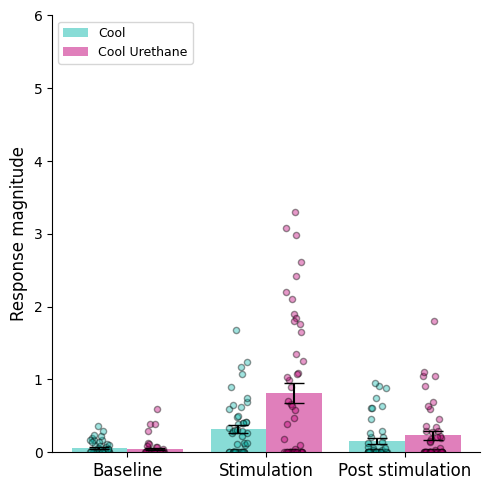

In [33]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Response_Magnitude.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_Response_Magnitude.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_cool_filtered = df_cool[df_cool['period_type'].isin(['TS', 'TB', 'PTS'])]
df_ure_filtered = df_ure[df_ure['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = df_cool_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_cool = df_cool_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

mean_ure = df_ure_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_ure = df_ure_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['response_magnitude'],
    'sem_response_cool': sem_cool['response_magnitude'],
    'mean_response_ure': mean_ure['response_magnitude'],
    'sem_response_ure': sem_ure['response_magnitude']
})

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    for cond in ['Cool', 'ure']:
        data_subset = df_cool_filtered if cond == 'Cool' else df_ure_filtered
        period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']
        
        # Affichage du nombre d'observations (n)
        n = len(period_data)
        
        # Test de normalité Shapiro
        stat, p_value = shapiro(period_data)
        normality_results[period][cond] = {'statistic': stat, 'p_value': p_value}
        
      # Affichage des résultats du test de normalité et de la taille d'échantillon
        print(f"\n{cond}-{period} : {np.mean(period_data):.4f} ± {stats.sem(period_data):.4f}, n = {n}")
        print(f"  Test de Shapiro-Wilk : Stat = {stat:.4f}, p-value = {p_value:.4f}")

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Cool Urethane', color='#c20078', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = df_cool_filtered[df_cool_filtered['period_type'] == period]['response_magnitude']
    ure_values = df_ure_filtered[df_ure_filtered['period_type'] == period]['response_magnitude']
    
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.07  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#c20078', edgecolor='black', s=20, alpha=0.4)

# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim (0,6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

plt.show()


#### Fichier merged Cool-urethane response magnitude for R stat

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_Response_Magnitude.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Thq_ure_Response_Magnitude.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(cool_file_path)
df_auc_ure = pd.read_excel(ure_file_path)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_cool, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']
Conditions = ['Cool', 'Ure']

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Resp_magnitude_Combined_thq_ure.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Thresholding_Thq_vs_Ure/Resp_magnitude_Combined_thq_ure.xlsx


# 7. Combo heatmap - PTSC

La valeur maximale de Znorm entre 0 et 3.9 secondes est : 4.771583141019931


C:\Users\zayan\AppData\Local\Temp\ipykernel_93176\3296468491.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined = df_cool.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_93176\3296468491.py:274: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


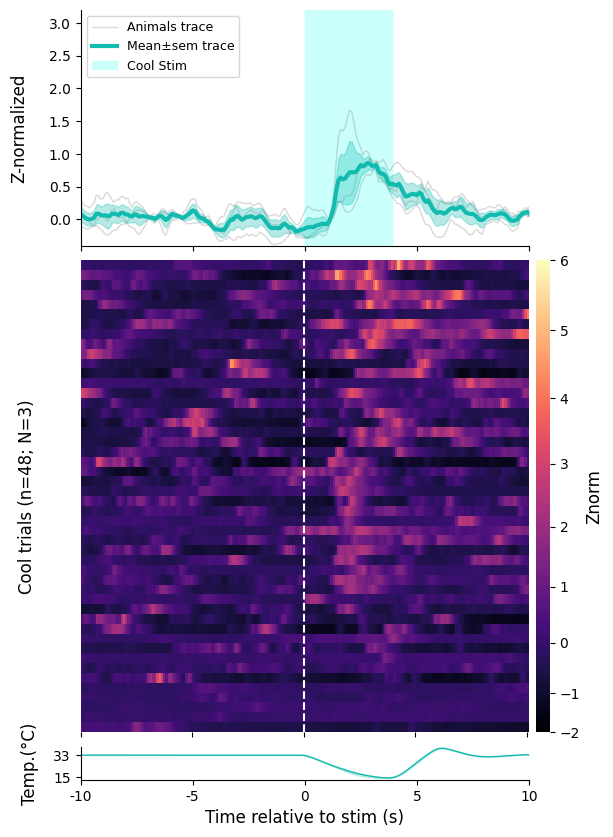

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_Thq_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory_cool, 'Df_thq_Zscore_classic_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes



########################################################## HEATMAP #####################################################################

# Lire les fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_thq_Zscore_classic.xlsx'
df_cool = pd.read_excel(file_path_cool)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_cool['Znorm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'rec', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['rec'] == row['rec']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

# Appliquer aux deux DataFrames
add_stim_column(df_cool, 'Cool')

# Convertir Stim_Time en secondes dans les deux DataFrames
df_cool['Stim_Time_sec'] = df_cool['Stim_Time'] / 1000

# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered = df_cool[(df_cool['Stim_Time_sec'] >= 0) & (df_cool['Stim_Time_sec'] <= 3.9)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered['Znorm'].max()

print("La valeur maximale de Znorm entre 0 et 3.9 secondes est :", max_znorm_value)

# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_cool_filtered = df_cool[(df_cool['Stim_Time_sec'] >= 0) & (df_cool['Stim_Time_sec'] <= 10)]
trial_sums = df_cool_filtered.groupby('Stim')['Znorm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_cool['Stim'] = pd.Categorical(df_cool['Stim'], categories=trial_sums.index, ordered=True)
df_cool = df_cool.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined = df_cool.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
df_heatmap_combined = df_heatmap_combined.join(df_cool[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))

# Trouver l'index où les conditions 'Hot' commencent
num_cool_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Cool'])

# Préparer les données pour la variation de température moyenne
temp_mean_cool = df_cool.groupby('Stim_Time_sec')['temperature'].mean()


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)
# gs = gridspec.GridSpec(nrows=3, ncols=3, width_ratios=[10, 1, 0.1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#cafffb'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1,alpha=0.3, label='Animals trace')  # Légende unique


# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#13bbaf', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#13bbaf', alpha=0.3, zorder=2, label=None
    )

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Ajuster les limites de l'axe y
ax0.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Calculer la différence entre les limites y_graph et y_data
y_min_diff = ax0.get_ylim()[0] - y_min
y_max_diff = ax0.get_ylim()[1] - y_max

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 5 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Cool Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad=15)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.4, 3.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials Cool
num_cool_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Cool'])
ax1.text(-20, num_cool_trials / 2, f'Cool trials (n={num_cool_trials}; N=3)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')

###

################# Variation de température  #################

ax2 = plt.subplot(gs[2, 0])

sns.lineplot(
    data=df_combined, x='time_sec', y='Mean_temperature', 
    color='#13bbaf', linewidth=1, ax=ax2, # color = topaz
)

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_xlim(-10, 10)
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])

# Enlever les bordures du haut et de droite
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()



plt.show()

La valeur maximale de Znorm entre 0 et 3.9 secondes est : 9.18208309221845


C:\Users\zayan\AppData\Local\Temp\ipykernel_93176\619347349.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined = df_ure.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_93176\619347349.py:274: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


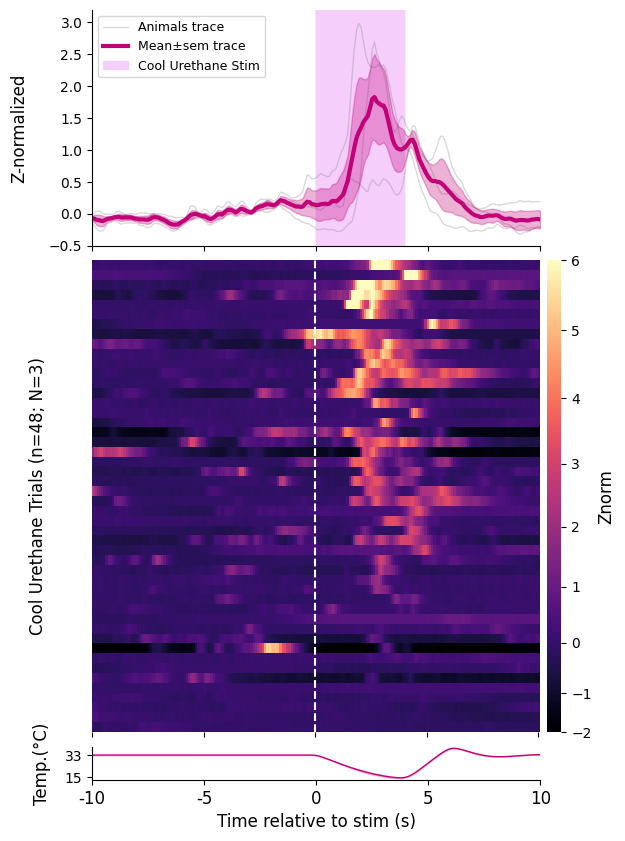

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_Thq_ure_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory_ure, 'Df_thq_ure_Zscore_classic_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes



########################################################## HEATMAP #####################################################################

# Lire les fichiers Excel
file_path_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_vs_Thq_ure_2/Df_thq_ure_Zscore_classic_stim.xlsx'
df_ure = pd.read_excel(file_path_ure)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_ure['Znorm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'rec', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['rec'] == row['rec']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

# Appliquer aux deux DataFrames
add_stim_column(df_ure, 'ure')

# Convertir Stim_Time en secondes dans les deux DataFrames
df_ure['Stim_Time_sec'] = df_ure['Stim_Time'] / 1000

# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered = df_ure[(df_ure['Stim_Time_sec'] >= 0) & (df_ure['Stim_Time_sec'] <= 3.9)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered['Znorm'].max()

print("La valeur maximale de Znorm entre 0 et 3.9 secondes est :", max_znorm_value)

# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_ure_filtered = df_ure[(df_ure['Stim_Time_sec'] >= 0) & (df_ure['Stim_Time_sec'] <= 10)]
trial_sums = df_ure_filtered.groupby('Stim')['Znorm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_ure['Stim'] = pd.Categorical(df_ure['Stim'], categories=trial_sums.index, ordered=True)
df_ure = df_ure.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined = df_ure.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
df_heatmap_combined = df_heatmap_combined.join(df_ure[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))

# Trouver l'index où les conditions 'Hot' commencent
num_ure_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'ure'])

# Préparer les données pour la variation de température moyenne
temp_mean_ure = df_ure.groupby('Stim_Time_sec')['temperature'].mean()


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)
# gs = gridspec.GridSpec(nrows=3, ncols=3, width_ratios=[10, 1, 0.1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#f6cefc'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1,alpha=0.3, label='Animals trace')  # Légende unique


# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#c20078', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#c20078', alpha=0.3, zorder=2, label=None
    )

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Ajuster les limites de l'axe y
ax0.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Calculer la différence entre les limites y_graph et y_data
y_min_diff = ax0.get_ylim()[0] - y_min
y_max_diff = ax0.get_ylim()[1] - y_max

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 5 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Cool Urethane Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad=15)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.5, 3.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials Urethane
num_ure_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'ure'])
ax1.text(-20, num_ure_trials / 2, f'Cool Urethane Trials (n={num_ure_trials}; N=3)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')

###

################# Variation de température  #################

ax2 = plt.subplot(gs[2, 0])

sns.lineplot(
    data=df_combined, x='time_sec', y='Mean_temperature', 
    color='#c20078', linewidth=1, ax=ax2, # color = topaz
)

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_xlim(-10, 10)
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])

# Enlever les bordures du haut et de droite
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()


plt.show()